# Advection Equation

We solve $u_t + c u_x = 0$ and visualize transport over time.


## Discretization and snapshots


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

import ipywidgets as widgets
n = 260
x = np.linspace(0, 1, n, endpoint=False)
dx = x[1] - x[0]
c = 0.7
dt = 0.45 * dx / c
steps = 220
u = np.exp(-((x-0.25)/0.08)**2) + 0.7*np.exp(-((x-0.65)/0.05)**2)
snaps = [u.copy()]
for _ in range(steps):
    u = u - c * dt / dx * (u - np.roll(u, 1))
    snaps.append(u.copy())
snaps = np.array(snaps)


## Progressive results


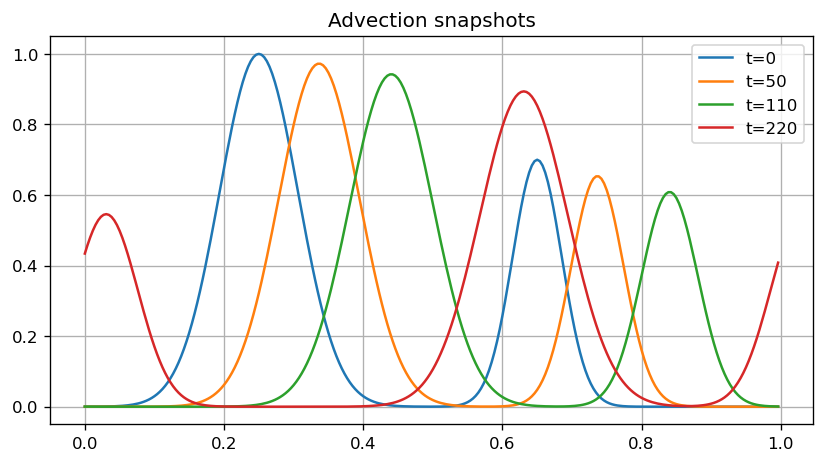

In [2]:
fig, ax = plt.subplots(figsize=(8.2, 4.2))
for t in [0, 50, 110, 220]:
    ax.plot(x, snaps[t], lw=1.5, label=f"t={t}")
ax.legend(); ax.set_title("Advection snapshots")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Interactive time slider
